## Step 1 — Load Data

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 999)
data_dir = "/Users/kiraaz/Desktop/march-machine-learning-mania-2026"

# M = men's, W = women's
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

M_coaches = pd.read_csv(f"{data_dir}/MTeamCoaches.csv")

In [6]:
# stack men's and women's into one dataframe
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

In [7]:
season = 2003  # data starts here; bump this up if you want a shorter training window
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]

## Step 2 — Quick Look at the Data

In [8]:
regular_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85500,2026,93,3421,60,3149,48,A,0,20,56,5,13,15,24,9,33,8,11,0,0,23,14,58,5,21,15,21,4,22,8,7,4,5,22
85501,2026,93,3428,67,3416,57,A,0,24,57,10,25,9,10,6,27,15,17,10,2,16,20,59,5,14,12,16,11,22,10,15,6,7,11
85502,2026,93,3437,67,3139,57,A,0,27,64,6,20,7,8,7,19,14,6,11,3,13,23,49,4,15,7,10,5,22,11,16,5,2,10
85503,2026,93,3452,61,3160,55,A,0,24,58,7,18,6,11,6,23,7,14,11,3,19,19,53,2,9,15,19,9,27,9,17,8,3,14


In [9]:
tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,2025,147,3163,78,3425,64,N,0,27,60,10,22,14,17,6,25,16,12,10,2,17,19,58,3,13,23,26,13,29,7,15,8,2,18
957,2025,147,3400,58,3395,47,N,0,24,61,2,3,8,11,11,23,14,8,9,6,20,12,45,4,20,19,21,11,27,8,21,1,3,14
958,2025,151,3163,85,3417,51,N,0,33,60,7,16,12,17,9,25,17,7,13,2,16,20,52,4,16,7,8,8,21,11,19,5,2,12
959,2025,151,3376,74,3400,57,N,0,29,57,7,11,9,12,10,26,17,13,7,5,15,22,56,4,10,9,12,9,20,10,14,6,5,17


In [10]:
# track one team's full 2024 run — regular season + tournament
season = 2024
teamid = 3163

r = regular_results.loc[
    (regular_results["Season"] == season)
    & ((regular_results["WTeamID"] == teamid) | (regular_results["LTeamID"] == teamid))
]
t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & ((tourney_results["WTeamID"] == teamid) | (tourney_results["LTeamID"] == teamid))
]
r["win"] = np.where(r["WTeamID"] == teamid, "win", "lose")
t["win"] = np.where(t["WTeamID"] == teamid, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
rt[["DayNum", "WScore", "LScore", "type", "win"]]

,DayNum,WScore,LScore,type,win
70978,2,102,58,regular season,win
71162,6,92,81,regular season,lose
71309,10,80,48,regular season,win
71432,13,62,44,regular season,win
71679,18,78,67,regular season,lose
71703,19,71,63,regular season,win
72099,27,80,68,regular season,lose
72161,30,90,63,regular season,win
72306,34,76,64,regular season,win
72433,40,86,62,regular season,win


In [11]:
seeds

,Season,Seed,TeamID
1154,2003,W01,1328
1155,2003,W02,1448
1156,2003,W03,1393
1157,2003,W04,1257
1158,2003,W05,1280
...,...,...,...
1739,2025,Z12,3193
1740,2025,Z13,3251
1741,2025,Z14,3195
1742,2025,Z15,3117


In [12]:
# seeds are split into 4 regions (W/X/Y/Z) — check the breakdown for one season
s = W_seeds.loc[W_seeds["Season"] == 2015]
[s.loc[s["Seed"].str.startswith(d)] for d in ("X", "Y", "Z", "W")]

[      Season Seed  TeamID
 1104    2015  X01    3268
 1105    2015  X02    3397
 1106    2015  X03    3333
 1107    2015  X04    3181
 1108    2015  X05    3280
 1109    2015  X06    3203
 1110    2015  X07    3151
 1111    2015  X08    3343
 1112    2015  X09    3453
 1113    2015  X10    3338
 1114    2015  X11    3211
 1115    2015  X12    3408
 1116    2015  X13    3107
 1117    2015  X14    3355
 1118    2015  X15    3129
 1119    2015  X16    3308,
       Season Seed  TeamID
 1120    2015  Y01    3376
 1121    2015  Y02    3199
 1122    2015  Y03    3113
 1123    2015  Y04    3314
 1124    2015  Y05    3326
 1125    2015  Y06    3401
 1126    2015  Y07    3195
 1127    2015  Y08    3393
 1128    2015  Y09    3304
 1129    2015  Y10    3329
 1130    2015  Y11    3114
 1131    2015  Y12    3241
 1132    2015  Y13    3251
 1133    2015  Y14    3325
 1134    2015  Y15    3106
 1135    2015  Y16    3366,
       Season Seed  TeamID
 1136    2015  Z01    3323
 1137    2015  Z02    3124

In [13]:
# what seed did this team get?
seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == teamid)]

,Season,Seed,TeamID
1660,2024,Z03,3163


## Step 3 — Data Prep

In [14]:
# flip each game so it appears from both teams' perspectives
# this doubles the dataset and removes the W/L labeling bias

def prepare_data(df):
    df = df.copy()
    # Map WLoc to numeric: H=1 (winner home), A=-1 (winner away), N=NaN (neutral)
    wloc_map = {'H': 1, 'A': -1, 'N': np.nan}
    df['WHome'] = df['WLoc'].map(wloc_map)

    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT", "WHome",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]].copy()

    # OT games accumulate more stats — normalize everything to 40-minute equivalent
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore",
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot

    dfswap = df.copy()
    df.columns    = [x.replace("W", "T1_").replace("L", "T2_") for x in df.columns]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in dfswap.columns]

    # If T1 is home (+1), T2 must be away (-1), and vice versa
    df["T2_Home"]    = -df["T1_Home"]
    dfswap["T1_Home"] = -dfswap["T2_Home"]

    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"]       = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1
    return output

regular_data = prepare_data(regular_results)
tourney_data  = prepare_data(tourney_results)

print("T1_Home in tourney_data:", "T1_Home" in tourney_data.columns)
print(tourney_data[["T1_Home", "T2_Home"]].value_counts(dropna=False).head())

T1_Home in tourney_data: True
T1_Home  T2_Home
 NaN      NaN       4062
-1.0      1.0        379
 1.0     -1.0        379
Name: count, dtype: int64


In [15]:
regular_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T2_Home,PointDiff,win,men_women
0,2003,10,1328,62.0,1104,68.0,0,NaN,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,NaN,6.0,1,1
1,2003,10,1393,63.0,1272,70.0,0,NaN,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,NaN,7.0,1,1
2,2003,11,1437,61.0,1266,73.0,0,NaN,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,NaN,12.0,1,1
3,2003,11,1457,50.0,1296,56.0,0,NaN,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,NaN,6.0,1,1
4,2003,11,1208,71.0,1400,77.0,0,NaN,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,NaN,6.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416555,2026,93,3421,60.0,3149,48.0,0,1.0,20.0,56.0,5.0,13.0,15.0,24.0,9.0,33.0,8.0,11.0,0.0,0.0,23.0,14.0,58.0,5.0,21.0,15.0,21.0,4.0,22.0,8.0,7.0,4.0,5.0,22.0,-1.0,-12.0,0,0
416556,2026,93,3428,67.0,3416,57.0,0,1.0,24.0,57.0,10.0,25.0,9.0,10.0,6.0,27.0,15.0,17.0,10.0,2.0,16.0,20.0,59.0,5.0,14.0,12.0,16.0,11.0,22.0,10.0,15.0,6.0,7.0,11.0,-1.0,-10.0,0,0
416557,2026,93,3437,67.0,3139,57.0,0,1.0,27.0,64.0,6.0,20.0,7.0,8.0,7.0,19.0,14.0,6.0,11.0,3.0,13.0,23.0,49.0,4.0,15.0,7.0,10.0,5.0,22.0,11.0,16.0,5.0,2.0,10.0,-1.0,-10.0,0,0
416558,2026,93,3452,61.0,3160,55.0,0,1.0,24.0,58.0,7.0,18.0,6.0,11.0,6.0,23.0,7.0,14.0,11.0,3.0,19.0,19.0,53.0,2.0,9.0,15.0,19.0,9.0,27.0,9.0,17.0,8.0,3.0,14.0,-1.0,-6.0,0,0


In [16]:
tourney_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T2_Home,PointDiff,win,men_women
0,2003,134,1411,74.666667,1421,81.777778,1,NaN,25.777778,59.555556,10.666667,27.555556,12.444444,27.555556,15.111111,24.888889,14.222222,13.333333,4.444444,0.000000,19.555556,28.444444,61.333333,9.777778,25.777778,15.111111,23.111111,12.444444,26.666667,15.111111,10.666667,4.444444,2.666667,19.555556,NaN,7.111111,1,1
1,2003,136,1436,51.000000,1112,80.000000,0,NaN,20.000000,64.000000,4.000000,16.000000,7.000000,7.000000,8.000000,26.000000,12.000000,17.000000,10.000000,3.000000,15.000000,31.000000,66.000000,7.000000,23.000000,11.000000,14.000000,11.000000,36.000000,22.000000,16.000000,10.000000,7.000000,8.000000,NaN,29.000000,1,1
2,2003,136,1272,71.000000,1113,84.000000,0,NaN,25.000000,69.000000,7.000000,28.000000,14.000000,21.000000,20.000000,22.000000,11.000000,12.000000,2.000000,5.000000,18.000000,31.000000,59.000000,6.000000,14.000000,16.000000,22.000000,10.000000,27.000000,18.000000,9.000000,7.000000,4.000000,19.000000,NaN,13.000000,1,1
3,2003,136,1166,73.000000,1141,79.000000,0,NaN,27.000000,60.000000,7.000000,17.000000,12.000000,17.000000,14.000000,17.000000,20.000000,21.000000,6.000000,6.000000,21.000000,29.000000,53.000000,3.000000,7.000000,18.000000,25.000000,11.000000,20.000000,15.000000,18.000000,13.000000,1.000000,19.000000,NaN,6.000000,1,1
4,2003,136,1301,65.777778,1143,67.555556,1,NaN,22.222222,49.777778,8.000000,18.666667,13.333333,17.777778,8.888889,23.111111,14.222222,12.444444,4.444444,7.111111,16.888889,24.000000,56.888889,6.222222,17.777778,13.333333,20.444444,16.000000,17.777778,15.111111,11.555556,7.111111,1.777778,12.444444,NaN,1.777778,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4815,2025,147,3163,78.000000,3425,64.000000,0,NaN,27.000000,60.000000,10.000000,22.000000,14.000000,17.000000,6.000000,25.000000,16.000000,12.000000,10.000000,2.000000,17.000000,19.000000,58.000000,3.000000,13.000000,23.000000,26.000000,13.000000,29.000000,7.000000,15.000000,8.000000,2.000000,18.000000,NaN,-14.000000,0,0
4816,2025,147,3400,58.000000,3395,47.000000,0,NaN,24.000000,61.000000,2.000000,3.000000,8.000000,11.000000,11.000000,23.000000,14.000000,8.000000,9.000000,6.000000,20.000000,12.000000,45.000000,4.000000,20.000000,19.000000,21.000000,11.000000,27.000000,8.000000,21.000000,1.000000,3.000000,14.000000,NaN,-11.000000,0,0
4817,2025,151,3163,85.000000,3417,51.000000,0,NaN,33.000000,60.000000,7.000000,16.000000,12.000000,17.000000,9.000000,25.000000,17.000000,7.000000,13.000000,2.000000,16.000000,20.000000,52.000000,4.000000,16.000000,7.000000,8.000000,8.000000,21.000000,11.000000,19.000000,5.000000,2.000000,12.000000,NaN,-34.000000,0,0
4818,2025,151,3376,74.000000,3400,57.000000,0,NaN,29.000000,57.000000,7.000000,11.000000,9.000000,12.000000,10.000000,26.000000,17.000000,13.000000,7.000000,5.000000,15.000000,22.000000,56.000000,4.000000,10.000000,9.000000,12.000000,9.000000,20.000000,10.000000,14.000000,6.000000,5.000000,17.000000,NaN,-17.000000,0,0


In [17]:
# sanity check — the same game should appear twice with flipped scores
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T2_Home,PointDiff,win,men_women
118444,2025,120,1182,62.0,1433,71.0,0,-1.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,1.0,9.0,1,1
326724,2025,120,1433,71.0,1182,62.0,0,1.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,-1.0,-9.0,0,1


## Features — Tier 1: Basic (Seed)

In [18]:
# pull the seed number out of the string (e.g. "W01" → 1)
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
1739,2025,Z12,3193,12
1740,2025,Z13,3251,13
1741,2025,Z14,3195,14
1742,2025,Z15,3117,15


In [19]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


In [20]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

base_cols = ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]
home_cols = [c for c in ["T1_Home", "T2_Home"] if c in tourney_data.columns]
tourney_data = tourney_data[base_cols + home_cols]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

print("Home cols kept:", home_cols)
tourney_data

Home cols kept: []


,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


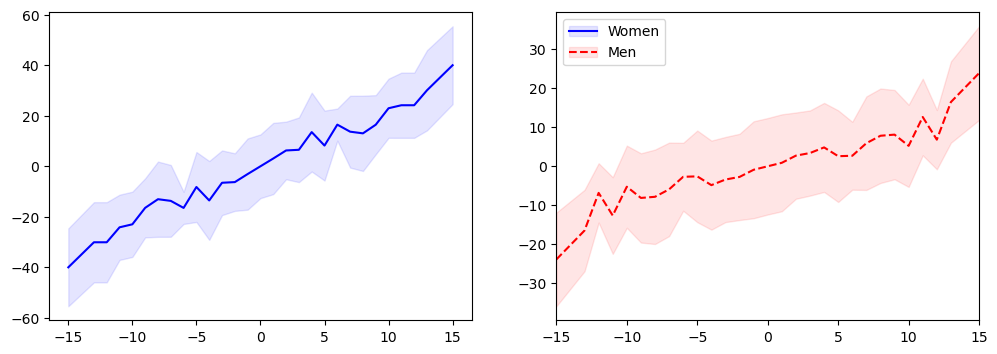

In [21]:
# same thing but for seed difference between the two teams
tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

## Features — Tier 2: Season Stats

In [22]:
# all the box score stats we want to aggregate into season averages
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

**The idea behind these features:**

For any matchup between **T1** and **T2**, we want to capture how each team performed throughout the regular season — not just their own stats, but also what their opponents tended to do against them.

Specifically, for each team **T** we compute two things:
- `average[T]` — T's own regular season averages (scoring, rebounding, etc.)
- `average[T_opponents]` — how T's opponents performed on average (measures defensive strength)

Then for a tournament game between T1 and T2, we attach both of these profiles for each side, giving the model a richer picture of the matchup than seed alone.

In [23]:
# compute each team's regular season averages, then join to tourney matchups
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,16.903704,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370

In [24]:
# FEATURE: Last-14-days win ratio
# Hot teams entering the tournament (DayNum > 118) tend to outperform their seed
late_season = regular_data.loc[regular_data["DayNum"] > 118].copy()
late_wins = late_season.groupby(["Season", "T1_TeamID"])["win"].agg(["sum", "count"]).reset_index()
late_wins.columns = ["Season", "TeamID", "late_wins", "late_games"]
late_wins["WinRatio14d"] = late_wins["late_wins"] / late_wins["late_games"]

late_T1 = late_wins.rename({"TeamID": "T1_TeamID", "WinRatio14d": "T1_WinRatio14d"}, axis=1)[["Season","T1_TeamID","T1_WinRatio14d"]]
late_T2 = late_wins.rename({"TeamID": "T2_TeamID", "WinRatio14d": "T2_WinRatio14d"}, axis=1)[["Season","T2_TeamID","T2_WinRatio14d"]]

tourney_data = pd.merge(tourney_data, late_T1, on=["Season","T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, late_T2, on=["Season","T2_TeamID"], how="left")

# FEATURE: Full-season win ratio
# Simple but effective baseline — complements the late-season form above
away_data = regular_data.loc[regular_data["T1_TeamID"].notna()].copy()

all_wins = regular_data.groupby(["Season","T1_TeamID"])["win"].agg(["sum","count"]).reset_index()
all_wins.columns = ["Season","TeamID","wins","games"]
all_wins["awins"] = all_wins["wins"] / all_wins["games"]

awins_T1 = all_wins.rename({"TeamID":"T1_TeamID","awins":"T1_awins"},axis=1)[["Season","T1_TeamID","T1_awins"]]
awins_T2 = all_wins.rename({"TeamID":"T2_TeamID","awins":"T2_awins"},axis=1)[["Season","T2_TeamID","T2_awins"]]

tourney_data = pd.merge(tourney_data, awins_T1, on=["Season","T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, awins_T2, on=["Season","T2_TeamID"], how="left")

# FEATURE: Head-to-head win rate (Laplace-smoothed)
# If the two teams have played before, that history matters
# Laplace smoothing (wins+1)/(games+2) prevents 0 or 1 extremes for rare matchups
h2h = {}
for _, row in regular_results.iterrows():
    key = (row["Season"], int(row["WTeamID"]), int(row["LTeamID"]))
    rkey = (row["Season"], int(row["LTeamID"]), int(row["WTeamID"]))
    h2h[key] = h2h.get(key, [0, 0])
    h2h[key][0] += 1; h2h[key][1] += 1
    h2h[rkey] = h2h.get(rkey, [0, 0])
    h2h[rkey][1] += 1

def laplace_matchup(season, t1, t2):
    key = (season, int(t1), int(t2))
    wins, games = h2h.get(key, [0, 0])
    return (wins + 1) / (games + 2)

tourney_data["laplace_matchup"] = tourney_data.apply(
    lambda r: laplace_matchup(r["Season"], r["T1_TeamID"], r["T2_TeamID"]), axis=1
)

print("New features added: T1_WinRatio14d, T2_WinRatio14d, T1_awins, T2_awins, laplace_matchup")
print(tourney_data[["T1_WinRatio14d","T2_WinRatio14d","T1_awins","T2_awins","laplace_matchup"]].describe())

New features added: T1_WinRatio14d, T2_WinRatio14d, T1_awins, T2_awins, laplace_matchup
       T1_WinRatio14d  T2_WinRatio14d     T1_awins     T2_awins  \
count     4820.000000     4820.000000  4820.000000  4820.000000   
mean         0.709994        0.709994     0.761217     0.761217   
std          0.273564        0.273564     0.107345     0.107345   
min          0.000000        0.000000     0.366667     0.366667   
25%          0.500000        0.500000     0.687500     0.687500   
50%          0.750000        0.750000     0.764706     0.764706   
75%          1.000000        1.000000     0.838710     0.838710   
max          1.000000        1.000000     1.000000     1.000000   

       laplace_matchup  
count      4820.000000  
mean          0.500000  
std           0.041018  
min           0.200000  
25%           0.500000  
50%           0.500000  
75%           0.500000  
max           0.800000  


In [ ]:

# ── IMPROVEMENT 1: WinRatio14d 时间窗口优化 ──────────────────────────────────
# 1a) 扫描 DayNum 阈值 100~125，找最优窗口（按 AUC 评估）
from sklearn.metrics import roc_auc_score

print("=== DayNum 阈值扫描（100 → 125，步长 5）===")
print(f"{'Threshold':>10} | {'AUC':>8} | {'Avg games/team':>15}")
print("-" * 40)

best_thresh, best_auc = None, 0
for thresh in range(100, 126, 5):
    tmp_late = regular_data.loc[regular_data["DayNum"] > thresh].copy()
    tmp_wins = tmp_late.groupby(["Season", "T1_TeamID"])["win"].agg(["sum", "count"]).reset_index()
    tmp_wins.columns = ["Season", "TeamID", "late_wins", "late_games"]
    tmp_wins["WinRatioTmp"] = tmp_wins["late_wins"] / tmp_wins["late_games"]

    tmp_T1 = tmp_wins.rename({"TeamID": "T1_TeamID", "WinRatioTmp": "T1_WinRatioTmp"}, axis=1)[["Season","T1_TeamID","T1_WinRatioTmp"]]
    tmp_df = pd.merge(tourney_data[["Season","T1_TeamID","T2_TeamID","T1_seed","T2_seed","result"]],
                      tmp_T1, on=["Season","T1_TeamID"], how="left")
    tmp_T2 = tmp_wins.rename({"TeamID": "T2_TeamID", "WinRatioTmp": "T2_WinRatioTmp"}, axis=1)[["Season","T2_TeamID","T2_WinRatioTmp"]]
    tmp_df = pd.merge(tmp_df, tmp_T2, on=["Season","T2_TeamID"], how="left")
    tmp_df["diff"] = tmp_df["T1_WinRatioTmp"].fillna(0.5) - tmp_df["T2_WinRatioTmp"].fillna(0.5)
    label = (tmp_df["result"] > 0).astype(int)
    auc = roc_auc_score(label, tmp_df["diff"])
    avg_games = tmp_wins["late_games"].mean()
    print(f"{thresh:>10} | {auc:>8.4f} | {avg_games:>15.1f}")
    if auc > best_auc:
        best_auc, best_thresh = auc, thresh

print(f"\n最优阈值: DayNum > {best_thresh}  (AUC = {best_auc:.4f})")

# 1b) 用最优阈值重建 WinRatio14d（覆盖 Cell 25 的值）
print(f"\n用 DayNum > {best_thresh} 重新计算 WinRatio14d ...")
late_season_opt = regular_data.loc[regular_data["DayNum"] > best_thresh].copy()
late_wins_opt = late_season_opt.groupby(["Season","T1_TeamID"])["win"].agg(["sum","count"]).reset_index()
late_wins_opt.columns = ["Season","TeamID","late_wins","late_games"]
late_wins_opt["WinRatio14d"] = late_wins_opt["late_wins"] / late_wins_opt["late_games"]

# 替换 tourney_data 中已有的 WinRatio14d 列
tourney_data.drop(columns=["T1_WinRatio14d","T2_WinRatio14d"], errors="ignore", inplace=True)
lw_T1 = late_wins_opt.rename({"TeamID":"T1_TeamID","WinRatio14d":"T1_WinRatio14d"}, axis=1)[["Season","T1_TeamID","T1_WinRatio14d"]]
lw_T2 = late_wins_opt.rename({"TeamID":"T2_TeamID","WinRatio14d":"T2_WinRatio14d"}, axis=1)[["Season","T2_TeamID","T2_WinRatio14d"]]
tourney_data = pd.merge(tourney_data, lw_T1, on=["Season","T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, lw_T2, on=["Season","T2_TeamID"], how="left")

# 1c) 新特征：最后 10 场胜率 & 最后 10 场平均分差
print("\n计算最后 10 场胜率 (Last10WinRatio) 和平均分差 (Last10AvgScoreDiff) ...")

# 为每支队排序后取最后 10 场
reg_sorted = regular_data.sort_values(["Season","T1_TeamID","DayNum"])
last10 = (
    reg_sorted
    .groupby(["Season","T1_TeamID"])
    .tail(10)
    .groupby(["Season","T1_TeamID"])
    .agg(
        Last10WinRatio=("win", "mean"),
        Last10AvgScoreDiff=("T1_PointDiff", "mean"),
    )
    .reset_index()
    .rename(columns={"T1_TeamID": "TeamID"})
)

l10_T1 = last10.rename({"TeamID":"T1_TeamID","Last10WinRatio":"T1_Last10WinRatio","Last10AvgScoreDiff":"T1_Last10AvgScoreDiff"}, axis=1)
l10_T2 = last10.rename({"TeamID":"T2_TeamID","Last10WinRatio":"T2_Last10WinRatio","Last10AvgScoreDiff":"T2_Last10AvgScoreDiff"}, axis=1)

tourney_data = pd.merge(tourney_data, l10_T1[["Season","T1_TeamID","T1_Last10WinRatio","T1_Last10AvgScoreDiff"]],
                        on=["Season","T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, l10_T2[["Season","T2_TeamID","T2_Last10WinRatio","T2_Last10AvgScoreDiff"]],
                        on=["Season","T2_TeamID"], how="left")

print("新增特征: T1_Last10WinRatio, T2_Last10WinRatio, T1_Last10AvgScoreDiff, T2_Last10AvgScoreDiff")
print(tourney_data[["T1_Last10WinRatio","T2_Last10WinRatio","T1_Last10AvgScoreDiff","T2_Last10AvgScoreDiff"]].describe())


## Features — Tier 2.5: Coach Experience (Men's)

In [25]:
# FEATURE: Coach experience & historical performance
# Only available for men's; XGBoost handles NaN for women's natively.

# Step 1: For each team/season, take the end-of-season coach
end_coach = (
    M_coaches.sort_values("LastDayNum")
    .groupby(["Season", "TeamID"])
    .last()
    .reset_index()[["Season", "TeamID", "CoachName"]]
)

# Step 2: Compute regular-season wins per team/season
reg_wins = pd.concat([
    M_regular_results[["Season", "WTeamID"]].rename(columns={"WTeamID": "TeamID"}).assign(win=1),
    M_regular_results[["Season", "LTeamID"]].rename(columns={"LTeamID": "TeamID"}).assign(win=0),
])
reg_season_wins = reg_wins.groupby(["Season", "TeamID"])["win"].agg(["sum", "count"]).reset_index()
reg_season_wins.columns = ["Season", "TeamID", "wins", "games"]

# Step 3: Flag tournament appearances per team/season
tourney_teams = pd.concat([
    M_tourney_results[["Season", "WTeamID"]].rename(columns={"WTeamID": "TeamID"}),
    M_tourney_results[["Season", "LTeamID"]].rename(columns={"LTeamID": "TeamID"}),
]).drop_duplicates()
tourney_teams["made_tourney"] = 1

# Step 4: Build one row per coach/season with win stats + tourney flag
coach_season = (
    end_coach
    .merge(reg_season_wins, on=["Season", "TeamID"], how="left")
    .merge(tourney_teams, on=["Season", "TeamID"], how="left")
)
coach_season["made_tourney"] = coach_season["made_tourney"].fillna(0)
coach_season = coach_season.sort_values("Season")

# Step 5: Compute cumulative stats using only PRIOR seasons
coach_season["cum_wins"]    = coach_season.groupby("CoachName")["wins"].cumsum() - coach_season["wins"]
coach_season["cum_games"]   = coach_season.groupby("CoachName")["games"].cumsum() - coach_season["games"]
coach_season["cum_tourney"] = coach_season.groupby("CoachName")["made_tourney"].cumsum() - coach_season["made_tourney"]
coach_season["coach_exp"]   = coach_season.groupby("CoachName").cumcount()

coach_season["coach_career_winrate"] = (coach_season["cum_wins"] / coach_season["cum_games"]).fillna(0.5)
coach_season["coach_tourney_rate"]   = (coach_season["cum_tourney"] / coach_season["coach_exp"].clip(lower=1)).fillna(0.0)

coach_features = coach_season[["Season", "TeamID", "coach_exp", "coach_career_winrate", "coach_tourney_rate"]].copy()

# Step 6: Join to tourney_data as T1 / T2 features
coach_T1 = coach_features.rename(columns={
    "TeamID": "T1_TeamID",
    "coach_exp": "T1_coach_exp",
    "coach_career_winrate": "T1_coach_winrate",
    "coach_tourney_rate": "T1_coach_tourney_rate",
})
coach_T2 = coach_features.rename(columns={
    "TeamID": "T2_TeamID",
    "coach_exp": "T2_coach_exp",
    "coach_career_winrate": "T2_coach_winrate",
    "coach_tourney_rate": "T2_coach_tourney_rate",
})

# Drop existing coach cols to avoid _x/_y duplicates on re-run
coach_cols = ["T1_coach_exp", "T1_coach_winrate", "T1_coach_tourney_rate",
              "T2_coach_exp", "T2_coach_winrate", "T2_coach_tourney_rate"]
tourney_data = tourney_data.drop(columns=[c for c in coach_cols if c in tourney_data.columns])

tourney_data = tourney_data.merge(
    coach_T1[["Season", "T1_TeamID", "T1_coach_exp", "T1_coach_winrate", "T1_coach_tourney_rate"]],
    on=["Season", "T1_TeamID"], how="left"
)
tourney_data = tourney_data.merge(
    coach_T2[["Season", "T2_TeamID", "T2_coach_exp", "T2_coach_winrate", "T2_coach_tourney_rate"]],
    on=["Season", "T2_TeamID"], how="left"
)

print("Coach features added: T1/T2_coach_exp, T1/T2_coach_winrate, T1/T2_coach_tourney_rate")
print(tourney_data[["T1_coach_exp", "T1_coach_winrate", "T1_coach_tourney_rate"]].describe())

Coach features added: T1/T2_coach_exp, T1/T2_coach_winrate, T1/T2_coach_tourney_rate
       T1_coach_exp  T1_coach_winrate  T1_coach_tourney_rate
count   2898.000000       2898.000000            2898.000000
mean      12.716011          0.641417               0.309579
std        8.606523          0.118074               0.266123
min        0.000000          0.155844               0.000000
25%        5.000000          0.554581               0.066667
50%       12.000000          0.651346               0.272727
75%       19.000000          0.731034               0.500000
max       37.000000          0.935484               1.000000


## Features — Tier 3: ELO Rating

    k_factor  mean_loss
0         80   0.199613
1         90   0.199733
2         70   0.200014
3        100   0.200274
4         60   0.201076
5        110   0.201158
6        120   0.202329
7         50   0.203006
8        130   0.203739
9        140   0.205352
10        40   0.206115
11       150   0.207135
12       160   0.209060
best_k: 80,  best_loss: 0.19961


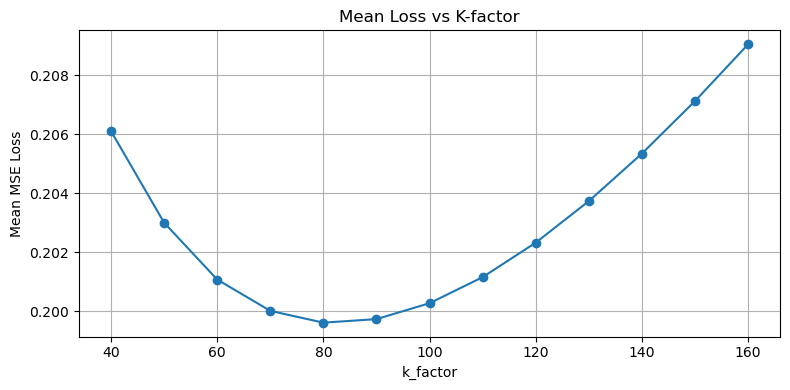

In [26]:
def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

def update_elo(winner_elo, loser_elo, k):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo

base_elo = 1000
elo_width = 400

def elo_fill(k):
    elos = []
    for season in sorted(set(seeds["Season"])):
        ss = regular_data.loc[regular_data["Season"] == season]
        ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
        teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
        elo = dict(zip(teams, [base_elo] * len(teams)))
        for i in range(ss.shape[0]):
            w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
            w_elo, l_elo = elo[w_team], elo[l_team]
            elo[w_team], elo[l_team] = update_elo(w_elo, l_elo, k)
        elo_df = pd.DataFrame.from_dict(elo, orient="index").reset_index()
        elo_df = elo_df.rename({"index": "TeamID", 0: "elo"}, axis=1)
        elo_df["Season"] = season
        elos.append(elo_df)
    return pd.concat(elos, ignore_index=True)

# Grid search for best k_factor
loss_dict = {}
for k in range(40, 161, 10):
    tourney_copy = tourney_data.copy()
    test = elo_fill(k)
    elos_T1 = test.rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
    elos_T2 = test.rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
    tourney_copy = pd.merge(tourney_copy, elos_T1, on=["Season", "T1_TeamID"], how="left")
    tourney_copy = pd.merge(tourney_copy, elos_T2, on=["Season", "T2_TeamID"], how="left")
    tourney_copy["expect"] = expected_result(tourney_copy["T1_elo"], tourney_copy["T2_elo"])
    season_loss = []
    for season in tourney_copy["Season"].unique():
        sub = tourney_copy[tourney_copy["Season"] == season]
        # 用 win 列作为 target，同时覆盖 T1/T2 赢的场次
        season_loss.append(((sub["expect"] - sub["win"]) ** 2).mean())
    loss_dict[k] = float(np.mean(season_loss))

loss_df = (
    pd.DataFrame([{"k_factor": k, "mean_loss": v} for k, v in loss_dict.items()])
    .sort_values("mean_loss")
    .reset_index(drop=True)
)
print(loss_df)

best_k = int(loss_df.loc[0, "k_factor"])
best_loss = float(loss_df.loc[0, "mean_loss"])
print(f"best_k: {best_k},  best_loss: {best_loss:.5f}")

plot_df = loss_df.sort_values("k_factor")
plt.figure(figsize=(8, 4))
plt.plot(plot_df["k_factor"], plot_df["mean_loss"], marker="o")
plt.xlabel("k_factor")
plt.ylabel("Mean MSE Loss")
plt.title("Mean Loss vs K-factor")
plt.grid(True)
plt.tight_layout()
plt.show()

# 用最优 k 生成最终 ELO，合并进 tourney_data
elos = elo_fill(best_k)
elos_T1 = elos.rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]


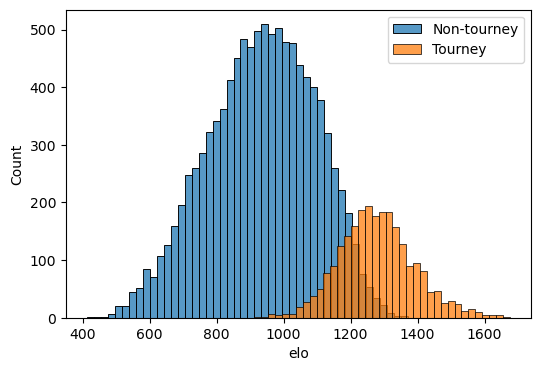

In [27]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')

plt.figure(figsize=(6,4))
seaborn.histplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False, label='Non-tourney')
seaborn.histplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False, label='Tourney')
plt.legend()

## Features — Tier 4: Massey Ordinals (Men's)

In [28]:
# Load Massey Ordinals (men's only, available from 2003)
massey = pd.read_csv(f"{data_dir}/MMasseyOrdinals.csv")

# Keep only pre-tournament rankings (tournament starts ~DayNum 134)
massey_pre = massey[massey["RankingDayNum"] <= 133].copy()

# For each season, find the last ranking day available
last_day = massey_pre.groupby("Season")["RankingDayNum"].max().reset_index()
last_day.columns = ["Season", "MaxDay"]
massey_pre = pd.merge(massey_pre, last_day, on="Season")
massey_final = massey_pre[massey_pre["RankingDayNum"] == massey_pre["MaxDay"]]

# Average rank across all rating systems per team per season
# Lower rank = better (rank 1 is the best team)
massey_avg = massey_final.groupby(["Season", "TeamID"])["OrdinalRank"].mean().reset_index()
massey_avg.columns = ["Season", "TeamID", "MasseyRank"]

print(f"Massey Ordinals: {massey['SystemName'].nunique()} rating systems, seasons {massey['Season'].min()}-{massey['Season'].max()}")
print(massey_avg.head())

# Drop columns if they already exist (safe to re-run)
for col in ["T1_MasseyRank", "T2_MasseyRank", "MasseyRank_diff"]:
    if col in tourney_data.columns:
        tourney_data = tourney_data.drop(columns=[col])

# Merge into tourney_data for T1 and T2
massey_T1 = massey_avg.rename(columns={"TeamID": "T1_TeamID", "MasseyRank": "T1_MasseyRank"})
massey_T2 = massey_avg.rename(columns={"TeamID": "T2_TeamID", "MasseyRank": "T2_MasseyRank"})

tourney_data = pd.merge(tourney_data, massey_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, massey_T2, on=["Season", "T2_TeamID"], how="left")

# Positive diff = T1 has better rank (lower number) vs T2
tourney_data["MasseyRank_diff"] = tourney_data["T2_MasseyRank"] - tourney_data["T1_MasseyRank"]

# Coverage check: women's teams will be NaN (XGBoost handles NaN natively)
coverage = tourney_data["T1_MasseyRank"].notna().mean()
print(f"\nMassey coverage in tourney_data: {coverage:.1%}")
print(tourney_data[["T1_MasseyRank", "T2_MasseyRank", "MasseyRank_diff"]].describe())

Massey Ordinals: 196 rating systems, seasons 2003-2026
   Season  TeamID  MasseyRank
0    2003    1102   156.03125
1    2003    1103   168.00000
2    2003    1104    38.03125
3    2003    1105   308.96875
4    2003    1106   262.68750

Massey coverage in tourney_data: 60.1%
       T1_MasseyRank  T2_MasseyRank  MasseyRank_diff
count    2898.000000    2898.000000      2898.000000
mean       41.206375      41.206375         0.000000
std        49.375161      49.375161        66.102580
min         1.037037       1.037037      -289.286413
25%        11.180328      11.180328       -25.687897
50%        24.481481      24.481481         0.000000
75%        46.217406      46.217406        25.687897
max       295.225806     295.225806       289.286413


<Axes: xlabel='T1_seed', ylabel='T1_elo'>

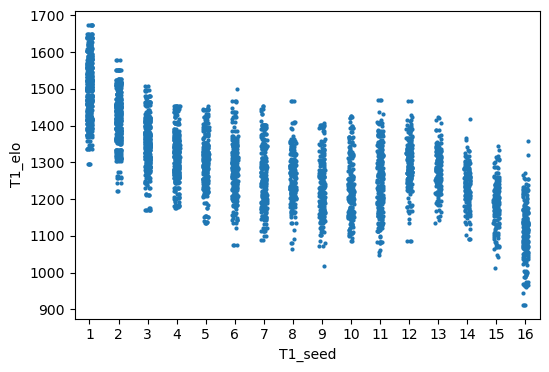

In [29]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

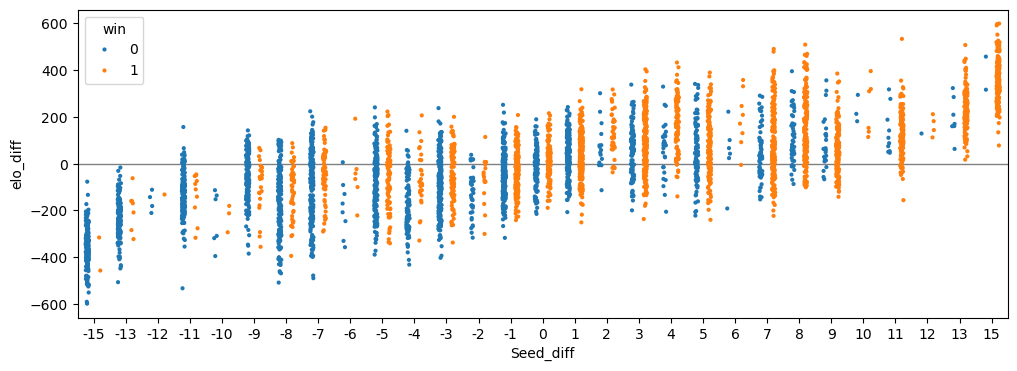

In [30]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
plt.axhline(y=0, color='gray', lw=1)

## Features — Tier 5: GLM Team Quality Score

In [31]:
import statsmodels.api as sm
import tqdm

regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

100%|██████████| 22/22 [05:15<00:00, 14.35s/season]


<Axes: ylabel='T1_quality'>

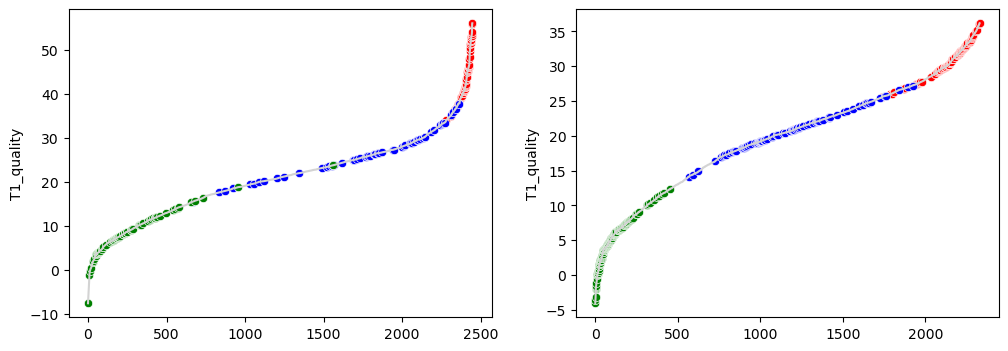

In [32]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])

In [33]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(data=tmp, index="T1_seed", columns="QualitySeed", values="men_women", aggfunc="count").fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


In [34]:
from sklearn.metrics import roc_auc_score

print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


In [35]:
# seed vs. GLM quality: which one called it better each year?
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


## Model Training — XGBoost + Leave-One-Season-Out CV

In [ ]:
features = [
    ### EASY FEATURES ###
    "men_women",
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    "T1_Home",   # +1 home, -1 away, NaN neutral (tournament games are almost always neutral)
    "T2_Home",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    "T1_avg_FGA",
    "T1_avg_OR",
    "T1_avg_DR",
    "T1_avg_Blk",
    "T1_avg_PF",
    "T1_avg_opponent_FGA",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    "T2_avg_FGA",
    "T2_avg_OR",
    "T2_avg_DR",
    "T2_avg_Blk",
    "T2_avg_PF",
    "T2_avg_opponent_FGA",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",
    "elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
    "diff_quality",
    ### ADDITIONAL FEATURES ###
    "T1_WinRatio14d",       # late-season form (optimized threshold)
    "T2_WinRatio14d",
    "T1_awins",             # full-season win ratio
    "T2_awins",
    "laplace_matchup",
    "T1_Last10WinRatio",    # last-10-games win ratio
    "T2_Last10WinRatio",
    "T1_Last10AvgScoreDiff", # last-10-games avg score diff
    "T2_Last10AvgScoreDiff",
    ### MASSEY ORDINALS (men's only, NaN for women — XGBoost handles natively) ###
    "T1_MasseyRank",
    "T2_MasseyRank",
    "MasseyRank_diff",
    ### COACH FEATURES (men's only, NaN for women — XGBoost handles natively) ###
    "T1_coach_exp",
    "T2_coach_exp",
    "T1_coach_winrate",
    "T2_coach_winrate",
    "T1_coach_tourney_rate",
    "T2_coach_tourney_rate",
]

print(f"Number of features: {len(features)}")


In [37]:
import xgboost as xgb
from sklearn.svm import SVR, NuSVR
from sklearn.preprocessing import StandardScaler

# Using Cauchy loss instead of MSE
def cauchyobj(preds, dtrain):
    labels = dtrain.get_label()
    c = 5000
    x = preds - labels
    x2 = x ** 2
    c2 = c ** 2
    grad = x / (x2 / c2 + 1)
    hess = -c2 * (x2 - c2) / (x2 + c2) ** 2
    return grad, hess

param = {}
param["booster"] = "gbtree"
param["eta"] = 0.02
param["subsample"] = 0.35
param["colsample_bynode"] = 0.8
param["num_parallel_tree"] = 10
param["min_child_weight"] = 40
param["max_depth"] = 4
param["gamma"] = 10
param["tree_method"] = "hist"
param["grow_policy"] = "lossguide"
param["max_bin"] = 32

num_rounds = 400

In [ ]:
from sklearn.metrics import mean_absolute_error, brier_score_loss
from sklearn.impute import SimpleImputer

# Only use features that actually exist in tourney_data (guards against stale kernel state)
active_features = [f for f in features if f in tourney_data.columns]
missing = set(features) - set(active_features)
if missing:
    print(f"⚠️  Skipping {len(missing)} features not in tourney_data: {sorted(missing)}")
print(f"Training with {len(active_features)} features")

# ── Sample Weight 时间衰减 ───────────────────────────────────────────────────
# 距离留出赛季越远的训练赛季权重越低：weight = decay_rate ^ |season - oof_season|
# decay_rate=1.0 等价于不加权（可作为超参数后续网格搜索）
DECAY_RATE = 0.9

def time_decay_weights(train_seasons: np.ndarray, oof_season: int, decay_rate: float) -> np.ndarray:
    """每条训练样本根据与留出赛季的距离赋权重。"""
    dist = np.abs(train_seasons - oof_season)
    return decay_rate ** dist
# ─────────────────────────────────────────────────────────────────────────────

models_xgb = {}
models_svm = {}
models_nusvm = {}
scalers = {}
imputers = {}
oof_mae_xgb = []
oof_mae_svm = []
oof_mae_nusvm = []
oof_mae_ensemble = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season-out cross validation
for oof_season in set(tourney_data.Season):
    train_mask = tourney_data["Season"] != oof_season
    val_mask   = tourney_data["Season"] == oof_season

    x_train = tourney_data.loc[train_mask, active_features].values
    y_train = tourney_data.loc[train_mask, "PointDiff"].values
    x_val   = tourney_data.loc[val_mask,   active_features].values
    y_val   = tourney_data.loc[val_mask,   "PointDiff"].values
    s_val   = tourney_data.loc[val_mask,   "Season"].values

    # 计算时间衰减权重
    train_seasons = tourney_data.loc[train_mask, "Season"].values
    sample_weights = time_decay_weights(train_seasons, oof_season, DECAY_RATE)

    # XGBoost (Cauchy loss) — 通过 DMatrix(weight=...) 传入权重，NaN 原生支持
    dtrain = xgb.DMatrix(x_train, label=y_train, weight=sample_weights)
    dval   = xgb.DMatrix(x_val,   label=y_val)
    models_xgb[oof_season] = xgb.train(
        params=param,
        dtrain=dtrain,
        num_boost_round=num_rounds,
        obj=cauchyobj,
    )
    preds_xgb = models_xgb[oof_season].predict(dval)

    # Impute NaN for sklearn models
    imputer = SimpleImputer(strategy="median")
    x_train_imp = imputer.fit_transform(x_train)
    x_val_imp   = imputer.transform(x_val)
    imputers[oof_season] = imputer

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_imp)
    x_val_scaled   = scaler.transform(x_val_imp)
    scalers[oof_season] = scaler

    # SVR — 通过 fit(sample_weight=...) 传入权重
    models_svm[oof_season] = SVR(C=1.0, epsilon=0.1, kernel='rbf')
    models_svm[oof_season].fit(x_train_scaled, y_train, sample_weight=sample_weights)
    preds_svm = models_svm[oof_season].predict(x_val_scaled)

    # NuSVR — 同上
    models_nusvm[oof_season] = NuSVR(nu=0.5, C=1.0, kernel='rbf')
    models_nusvm[oof_season].fit(x_train_scaled, y_train, sample_weight=sample_weights)
    preds_nusvm = models_nusvm[oof_season].predict(x_val_scaled)

    # Ensemble: equal average of XGB + SVR + NuSVR
    preds_ensemble = (preds_xgb + preds_svm + preds_nusvm) / 3.0

    print(f"oof season {oof_season} mae -> XGB: {mean_absolute_error(y_val, preds_xgb):.4f}, SVR: {mean_absolute_error(y_val, preds_svm):.4f}, NuSVR: {mean_absolute_error(y_val, preds_nusvm):.4f}, Ensemble: {mean_absolute_error(y_val, preds_ensemble):.4f}")

    oof_mae_xgb.append(mean_absolute_error(y_val, preds_xgb))
    oof_mae_svm.append(mean_absolute_error(y_val, preds_svm))
    oof_mae_nusvm.append(mean_absolute_error(y_val, preds_nusvm))
    oof_mae_ensemble.append(mean_absolute_error(y_val, preds_ensemble))
    oof_preds   += list(preds_ensemble)
    oof_targets += list(y_val)
    oof_ss      += list(s_val)

oof_mae = oof_mae_ensemble

print(f"\nAverage MAE -> XGB: {np.mean(oof_mae_xgb):.4f}, SVR: {np.mean(oof_mae_svm):.4f}, NuSVR: {np.mean(oof_mae_nusvm):.4f}, Ensemble: {np.mean(oof_mae_ensemble):.4f}")
print(f"(decay_rate={DECAY_RATE})")


In [ ]:
# ── 改进 3: 自动搜索最优 decay_rate ─────────────────────────────────────────
# Grid search decay_rate，用 Brier Score 评估，最后用最优值重跑完整模型

from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

DECAY_RATE_GRID = [0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 1.00]

def run_loso_cv(decay_rate):
    """运行完整 LOSO CV，返回 (oof_preds, oof_targets, oof_ss, models_xgb, models_svm, models_nusvm, scalers, imputers)。"""
    _models_xgb, _models_svm, _models_nusvm = {}, {}, {}
    _scalers, _imputers = {}, {}
    _oof_preds, _oof_targets, _oof_ss = [], [], []

    for oof_season in set(tourney_data.Season):
        train_mask = tourney_data["Season"] != oof_season
        val_mask   = tourney_data["Season"] == oof_season

        x_train = tourney_data.loc[train_mask, active_features].values
        y_train = tourney_data.loc[train_mask, "PointDiff"].values
        x_val   = tourney_data.loc[val_mask,   active_features].values
        y_val   = tourney_data.loc[val_mask,   "PointDiff"].values
        s_val   = tourney_data.loc[val_mask,   "Season"].values

        train_seasons  = tourney_data.loc[train_mask, "Season"].values
        sample_weights = time_decay_weights(train_seasons, oof_season, decay_rate)

        # XGBoost
        dtrain = xgb.DMatrix(x_train, label=y_train, weight=sample_weights)
        dval   = xgb.DMatrix(x_val,   label=y_val)
        _models_xgb[oof_season] = xgb.train(
            params=param, dtrain=dtrain, num_boost_round=num_rounds, obj=cauchyobj,
        )
        preds_xgb = _models_xgb[oof_season].predict(dval)

        # Impute + Scale
        imputer = SimpleImputer(strategy="median")
        x_train_imp = imputer.fit_transform(x_train)
        x_val_imp   = imputer.transform(x_val)
        _imputers[oof_season] = imputer

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train_imp)
        x_val_scaled   = scaler.transform(x_val_imp)
        _scalers[oof_season] = scaler

        # SVR
        _models_svm[oof_season] = SVR(C=1.0, epsilon=0.1, kernel='rbf')
        _models_svm[oof_season].fit(x_train_scaled, y_train, sample_weight=sample_weights)
        preds_svm = _models_svm[oof_season].predict(x_val_scaled)

        # NuSVR
        _models_nusvm[oof_season] = NuSVR(nu=0.5, C=1.0, kernel='rbf')
        _models_nusvm[oof_season].fit(x_train_scaled, y_train, sample_weight=sample_weights)
        preds_nusvm = _models_nusvm[oof_season].predict(x_val_scaled)

        preds_ensemble = (preds_xgb + preds_svm + preds_nusvm) / 3.0
        _oof_preds   += list(preds_ensemble)
        _oof_targets += list(y_val)
        _oof_ss      += list(s_val)

    return (_oof_preds, _oof_targets, _oof_ss,
            _models_xgb, _models_svm, _models_nusvm, _scalers, _imputers)


def brier_from_oof(oof_preds, oof_targets):
    """用 sigmoid(pred/scale) 做轻量级概率校准后计算 Brier Score。"""
    preds_arr   = np.array(oof_preds)
    targets_arr = np.array(oof_targets) > 0
    scale = np.std(preds_arr) * 2 + 1e-9          # 简单标准化
    probs = 1 / (1 + np.exp(-preds_arr / scale))
    return brier_score_loss(targets_arr, probs)


# ── Grid search ─────────────────────────────────────────────────────────────
print("decay_rate grid search 开始（共 {} 组）...\n".format(len(DECAY_RATE_GRID)))
gs_results = {}   # decay_rate -> brier_score

for dr in DECAY_RATE_GRID:
    print(f"  decay_rate = {dr:.2f} ...", end=" ", flush=True)
    preds, targets, ss, *_ = run_loso_cv(dr)
    bs = brier_from_oof(preds, targets)
    gs_results[dr] = bs
    print(f"Brier = {bs:.5f}")

best_dr   = min(gs_results, key=gs_results.get)
best_bs   = gs_results[best_dr]
print(f"\n最优 decay_rate = {best_dr}  (Brier = {best_bs:.5f})")

# ── 可视化 ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
drs = list(gs_results.keys())
bss = list(gs_results.values())
ax.plot(drs, bss, marker='o', linewidth=2, color='steelblue', label='Brier Score')
ax.axvline(best_dr, color='tomato', linestyle='--', linewidth=1.5, label=f'Best={best_dr}')
ax.scatter([best_dr], [best_bs], color='tomato', zorder=5, s=80)
ax.set_xlabel("decay_rate")
ax.set_ylabel("Brier Score (lower = better)")
ax.set_title("Sample Weight Decay Rate vs. Brier Score (LOSO CV)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 用最优 decay_rate 重跑最终模型，覆盖全局变量供后续 cell 使用 ─────────────
print(f"\n用 decay_rate={best_dr} 重跑完整模型 ...")
(oof_preds, oof_targets, oof_ss,
 models_xgb, models_svm, models_nusvm,
 scalers, imputers) = run_loso_cv(best_dr)

DECAY_RATE = best_dr   # 同步更新超参数变量
oof_mae = [mean_absolute_error([t], [p]) for t, p in zip(oof_targets, oof_preds)]
print(f"完成。平均 MAE = {np.mean(oof_mae):.4f}，Brier = {best_bs:.5f}  (decay_rate={DECAY_RATE})")



特征重要性汇总 (按总权重降序排列)
                  feature      sum         mean  count
0            diff_quality  83411.0  3791.409091     22
1                elo_diff  31528.0  1433.090909     22
2      T2_avg_opponent_PF  25797.0  1172.590909     22
3      T1_avg_opponent_PF  25675.0  1167.045455     22
4               Seed_diff  24693.0  1122.409091     22
5               T2_avg_PF  24293.0  1104.227273     22
6               T1_avg_PF  24173.0  1098.772727     22
7     T2_avg_opponent_Blk  23732.0  1078.727273     22
8     T2_avg_opponent_FGA  23448.0  1065.818182     22
9     T1_avg_opponent_Blk  23370.0  1062.272727     22
10              T1_avg_OR  23182.0  1053.727273     22
11    T1_avg_opponent_FGA  22835.0  1037.954545     22
12              T2_avg_OR  22626.0  1028.454545     22
13           T2_avg_Score  22157.0  1007.136364     22
14           T1_avg_Score  22034.0  1001.545455     22
15             T1_avg_FGA  21107.0   959.409091     22
16             T2_avg_FGA  21104.0   959.2727

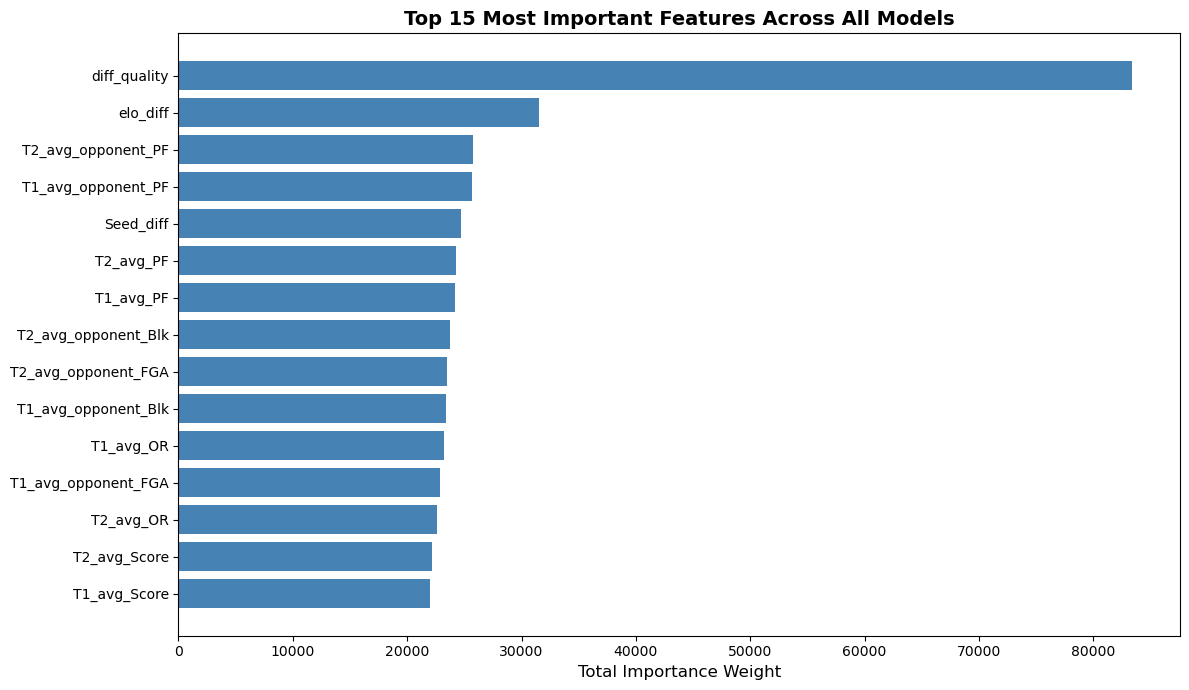


🏆 排名前 5 的最重要特征:
------------------------------------------------------------------------------------------
  1. diff_quality                        | 总权重:  83411.0 | 平均: 3791.41 | 使用: 22 次
  2. elo_diff                            | 总权重:  31528.0 | 平均: 1433.09 | 使用: 22 次
  3. T2_avg_opponent_PF                  | 总权重:  25797.0 | 平均: 1172.59 | 使用: 22 次
  4. T1_avg_opponent_PF                  | 总权重:  25675.0 | 平均: 1167.05 | 使用: 22 次
  5. Seed_diff                           | 总权重:  24693.0 | 平均: 1122.41 | 使用: 22 次


In [39]:
# 特征重要性分析 — 汇总所有模型的特征使用频率与权重
feature_importance_list = []
for season, model in models_xgb.items():
    importance = model.get_score(importance_type='weight')
    for feat_idx_str, score in importance.items():
        feat_idx = int(feat_idx_str.replace('f', ''))
        feature_importance_list.append({
            'feature': active_features[feat_idx],
            'importance': score,
            'season': season
        })

importance_df = pd.DataFrame(feature_importance_list)
importance_summary = importance_df.groupby('feature')['importance'].agg(['sum', 'mean', 'count']).reset_index()
importance_summary = importance_summary.sort_values('sum', ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("特征重要性汇总 (按总权重降序排列)")
print("=" * 90)
print(importance_summary.to_string())

# 可视化 Top 15 特征
plt.figure(figsize=(12, 7))
top_15 = importance_summary.head(15)
plt.barh(range(len(top_15)), top_15['sum'].values, color='steelblue')
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Total Importance Weight', fontsize=12)
plt.title('Top 15 Most Important Features Across All Models', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n🏆 排名前 5 的最重要特征:")
print("-" * 90)
for idx, (_, row) in enumerate(importance_summary.head(5).iterrows(), 1):
    print(f"  {idx}. {row['feature']:35s} | 总权重: {row['sum']:8.1f} | 平均: {row['mean']:6.2f} | 使用: {int(row['count'])} 次")

<Axes: xlabel='pred_pointdiff', ylabel='average_win_pct'>

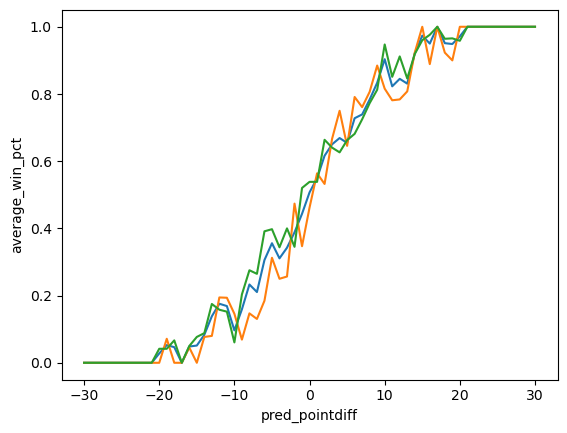

In [40]:
df = pd.DataFrame(
    {"Season": oof_ss, "pred": oof_preds, "label": [(t > 0) * 1 for t in oof_targets], "men_women": tourney_data["men_women"]}
)
df["pred_pointdiff"] = df["pred"].astype(int)

xdf_all = df.clip(-30, 30).groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_women = df.clip(-30, 30).loc[df["men_women"] == 0].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_men = df.clip(-30, 30).loc[df["men_women"] == 1].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")

seaborn.lineplot(x=xdf_all["pred_pointdiff"], y=xdf_all["average_win_pct"])
seaborn.lineplot(x=xdf_women["pred_pointdiff"], y=xdf_women["average_win_pct"])
seaborn.lineplot(x=xdf_men["pred_pointdiff"], y=xdf_men["average_win_pct"])

brier: 0.1646334463812225


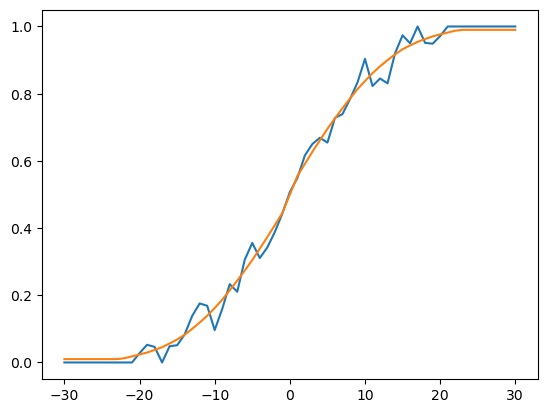

In [41]:
from scipy.interpolate import UnivariateSpline

t = 25
dat = list(zip(oof_preds, np.array(oof_targets)>0))
dat = sorted(dat, key = lambda x: x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=5)
spline_fit = np.clip(spline_model(np.clip(oof_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_pointdiff')[['spline','label']].mean().reset_index()

plt.figure()
plt.plot(xdf['pred_pointdiff'],xdf['label'])
plt.plot(xdf['pred_pointdiff'],xdf['spline'])

In [42]:
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")

for oof_season in set(tourney_data.Season):
    x = df.loc[df["Season"] == oof_season, "spline"].values
    y = df.loc[df["Season"] == oof_season, "label"].values
    print(oof_season, np.round(brier_score_loss(y, x),5))

brier: 0.1646334463812225
2003 0.18104
2004 0.17694
2005 0.17032
2006 0.19045
2007 0.14692
2008 0.14923
2009 0.16861
2010 0.17022
2011 0.1673
2012 0.14856
2013 0.17769
2014 0.16964
2015 0.14422
2016 0.16874
2017 0.16026
2018 0.17754
2019 0.14346
2021 0.17965
2022 0.1838
2023 0.18031
2024 0.1575
2025 0.12589


## Final Step — Generate Submission

In [43]:
# build all possible 2025 matchup pairs to predict
all_teams_2025 = sorted(set(
    regular_data.loc[regular_data["Season"] == 2025, "T1_TeamID"].unique().tolist()
))
from itertools import combinations
pairs = list(combinations(all_teams_2025, 2))
X = pd.DataFrame({"ID": [f"2025_{int(t1)}_{int(t2)}" for t1, t2 in pairs], "Pred": 0.5})

# parse team IDs and attach all features to the submission frame
X['Season'] = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))
X['men_women'] = X['T1_TeamID'].apply(lambda t: 1 if str(t)[0]=='1' else 0)  # 1=men, 0=women

# season stats
X = pd.merge(X, ss_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, ss_T2, on=['Season', 'T2_TeamID'], how='left')
# seeds
X = pd.merge(X, seeds_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, seeds_T2, on=['Season', 'T2_TeamID'], how='left')
# GLM quality
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
# ELO
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")
X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

# late-season form + win ratio + head-to-head
X = pd.merge(X, late_T1, on=["Season","T1_TeamID"], how="left")
X = pd.merge(X, late_T2, on=["Season","T2_TeamID"], how="left")
X = pd.merge(X, awins_T1, on=["Season","T1_TeamID"], how="left")
X = pd.merge(X, awins_T2, on=["Season","T2_TeamID"], how="left")
X["laplace_matchup"] = X.apply(
    lambda r: laplace_matchup(r["Season"], r["T1_TeamID"], r["T2_TeamID"]), axis=1
)

# Massey Ordinals features (men's only)
X = pd.merge(X, massey_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, massey_T2, on=["Season", "T2_TeamID"], how="left")
X["MasseyRank_diff"] = X["T2_MasseyRank"] - X["T1_MasseyRank"]

# Coach features (men's only)
X = pd.merge(X, coach_T1[["Season", "T1_TeamID", "T1_coach_exp", "T1_coach_winrate", "T1_coach_tourney_rate"]], on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, coach_T2[["Season", "T2_TeamID", "T2_coach_exp", "T2_coach_winrate", "T2_coach_tourney_rate"]], on=["Season", "T2_TeamID"], how="left")

print(f"Submission frame shape: {X.shape}")
X.head()

Submission frame shape: (263175, 89)


,ID,Pred,Season,T1_TeamID,T2_TeamID,men_women,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T1_seed,ST1,T2_seed,ST2,T1_quality,T2_quality,T1_elo,T2_elo,Seed_diff,elo_diff,diff_quality,T1_WinRatio14d,T2_WinRatio14d,T1_awins,T2_awins,laplace_matchup,T1_MasseyRank,T2_MasseyRank,MasseyRank_diff,T1_coach_exp,T1_coach_winrate,T1_coach_tourney_rate,T2_coach_exp,T2_coach_winrate,T2_coach_tourney_rate
0,2025_1101_1102,0.5,2025,1101,1102,1,66.94636,23.977011,55.724138,4.049808,14.088123,14.942529,20.793103,8.56705,19.421456,12.367816,14.072797,9.94636,2.877395,21.264368,70.386973,23.436782,50.862069,5.398467,16.563218,18.114943,26.149425,8.681992,22.413793,12.099617,15.908046,7.823755,4.636015,17.605364,-3.440613,61.423611,21.097222,50.128472,8.013889,24.260417,11.215278,17.684028,5.881944,20.784722,13.267361,12.111111,5.614583,2.829861,17.701389,73.149306,26.218750,54.517361,7.184028,19.763889,13.527778,19.319444,7.868056,23.725694,12.777778,9.625000,6.767361,3.177083,17.291667,-11.725694,NaN,NaN,NaN,NaN,2.19672,NaN,957.449906,688.437467,NaN,269.012440,NaN,0.333333,0.0,0.448276,0.125000,0.5,226.962963,314.518519,87.555556,3.0,0.488372,0.0,20.0,0.479167,0.050000
1,2025_1101_1103,0.5,2025,1101,1103,1,66.94636,23.977011,55.724138,4.049808,14.088123,14.942529,20.793103,8.56705,19.421456,12.367816,14.072797,9.94636,2.877395,21.264368,70.386973,23.436782,50.862069,5.398467,16.563218,18.114943,26.149425,8.681992,22.413793,12.099617,15.908046,7.823755,4.636015,17.605364,-3.440613,83.708333,30.121528,63.850694,10.621528,28.975694,12.843750,17.142361,9.913194,24.770833,17.621528,11.701389,7.531250,3.708333,18.243056,75.628472,26.569444,61.121528,7.406250,23.239583,15.083333,20.666667,8.805556,21.510417,11.888889,11.954861,7.159722,2.406250,16.777778,8.079861,NaN,NaN,13.0,2025/1103,2.19672,11.381115,957.449906,1303.999744,NaN,-346.549838,-9.184395,0.333333,1.0,0.448276,0.812500,0.5,226.962963,82.925926,-144.037037,3.0,0.488372,0.0,15.0,0.595745,0.333333
2,2025_1101_1104,0.5,2025,1101,1104,1,66.94636,23.977011,55.724138,4.049808,14.088123,14.942529,20.793103,8.56705,19.421456,12.367816,14.072797,9.94636,2.877395,21.264368,70.386973,23.436782,50.862069,5.398467,16.563218,18.114943,26.149425,8.681992,22.413793,12.099617,15.908046,7.823755,4.636015,17.605364,-3.440613,90.521886,30.898990,63.996633,10.363636,29.612795,18.360269,25.629630,10.885522,28.175084,16.680135,12.030303,6.030303,4.424242,18.878788,80.848485,28.710438,67.626263,7.309764,23.757576,16.117845,22.892256,10.276094,22.434343,12.558923,9.989899,7.764310,4.185185,20.649832,9.673401,NaN,NaN,2.0,2025/1104,2.19672,32.243481,957.449906,1404.163002,NaN,-446.713096,-30.046761,0.333333,0.5,0.448276,0.757576,0.5,226.962963,5.553571,-221.409392,3.0,0.488372,0.0,9.0,0.687500,0.777778
3,2025_1101_1105,0.5,2025,1101,1105,1,66.94636,23.977011,55.724138,4.049808,14.088123,14.942529,20.793103,8.56705,19.421456,12.367816,14.072797,9.94636,2.877395,21.264368,70.386973,23.436782,50.862069,5.398467,16.563218,18.114943,26.149425,8.681992,22.413793,12.099617,15.908046,7.823755,4.636015,17.605364,-3.440613,68.136886,22.767677,58.836642,7.504006,24.442355,15.097527,22.6

In [44]:
# run XGB + SVR + NuSVR ensemble on the submission set
preds_xgb_sub = []
preds_svm_sub = []
preds_nusvm_sub = []
for oof_season in set(tourney_data.Season):
    # XGBoost (handles NaN natively)
    dtest = xgb.DMatrix(X[active_features].values)
    preds_xgb_sub.append(models_xgb[oof_season].predict(dtest))

    # SVR + NuSVR — apply same imputer + scaler used during training
    x_test_imp = imputers[oof_season].transform(X[active_features].values)
    x_test_scaled = scalers[oof_season].transform(x_test_imp)
    preds_svm_sub.append(models_svm[oof_season].predict(x_test_scaled))
    preds_nusvm_sub.append(models_nusvm[oof_season].predict(x_test_scaled))

# Average across all seasons, then blend three models equally
margin_preds_xgb = np.array(preds_xgb_sub).mean(axis=0)
margin_preds_svm = np.array(preds_svm_sub).mean(axis=0)
margin_preds_nusvm = np.array(preds_nusvm_sub).mean(axis=0)
margin_preds_ensemble = (margin_preds_xgb + margin_preds_svm + margin_preds_nusvm) / 3.0

X['Pred'] = np.clip(spline_model(np.clip(margin_preds_ensemble, -t, t)), 0.01, 0.99)

In [45]:
# clip extreme probabilities to avoid log-loss blowup on overconfident predictions
X['Pred'] = X['Pred'].clip(0.01, 0.99).round(6)

In [47]:
X[['ID','Pred']].to_csv('/Users/kiraaz/Downloads/predictions.csv', index=None)
print(f"Saved {len(X)} predictions to /Users/ziqiwei/Downloads/predictions.csv")

Saved 263175 predictions to /Users/ziqiwei/Downloads/predictions.csv
